# Zápočtová úloha: Modelování a simulace dynamických systémů

Tento sešit obsahuje kompletní vypracování tří úloh zaměřených na numerické modelování, diferenciální rovnice, epidemiologii a stochastické simulace Monte Carlo. Cílem je demonstrovat schopnost implementovat modely, vizualizovat jejich chování a interpretovat výsledky.

---

## Úloha 1: Lineární a nelineární oscilátory

V této úloze analyzujeme a porovnáváme chování tlumených lineárních oscilátorů a nelineárních oscilátorů (Duffing a Van der Pol).

### Matematické modely a přepis na soustavy ODE

#### 1. Lineární tlumený a buzený oscilátor
$$m\ddot{x} + b\dot{x} + kx = F_0 \cos(\omega t)$$
Přepis na soustavu ($x_1 = x, x_2 = \dot{x}$):
$$\dot{x}_1 = x_2$$
$$\dot{x}_2 = -\frac{b}{m}x_2 - \frac{k}{m}x_1 + \frac{F_0}{m} \cos(\omega t)$$

#### 2. Duffingův oscilátor
$$\ddot{x} + \delta\dot{x} + \alpha x + \beta x^3 = \gamma \cos(\omega t)$$
$$\dot{x}_1 = x_2$$
$$\dot{x}_2 = -\delta x_2 - \alpha x_1 - \beta x_1^3 + \gamma \cos(\omega t)$$

#### 3. Van der Polův oscilátor
$$\ddot{x} - \mu(1 - x^2)\dot{x} + x = 0$$
$$\dot{x}_1 = x_2$$
$$\dot{x}_2 = \mu(1 - x_1^2)x_2 - x_1$$

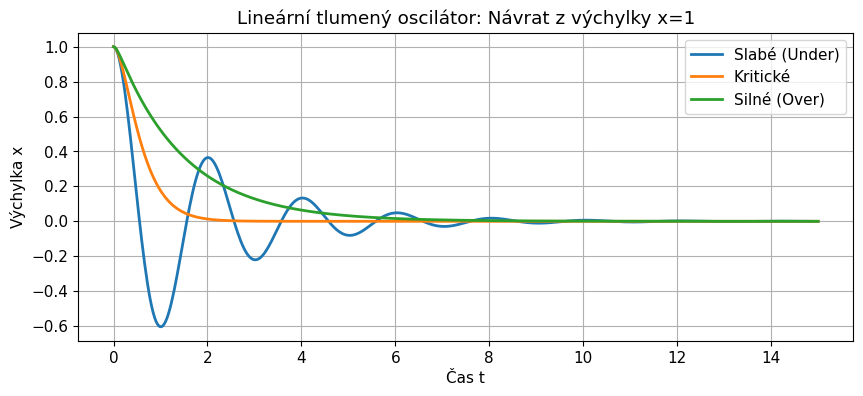

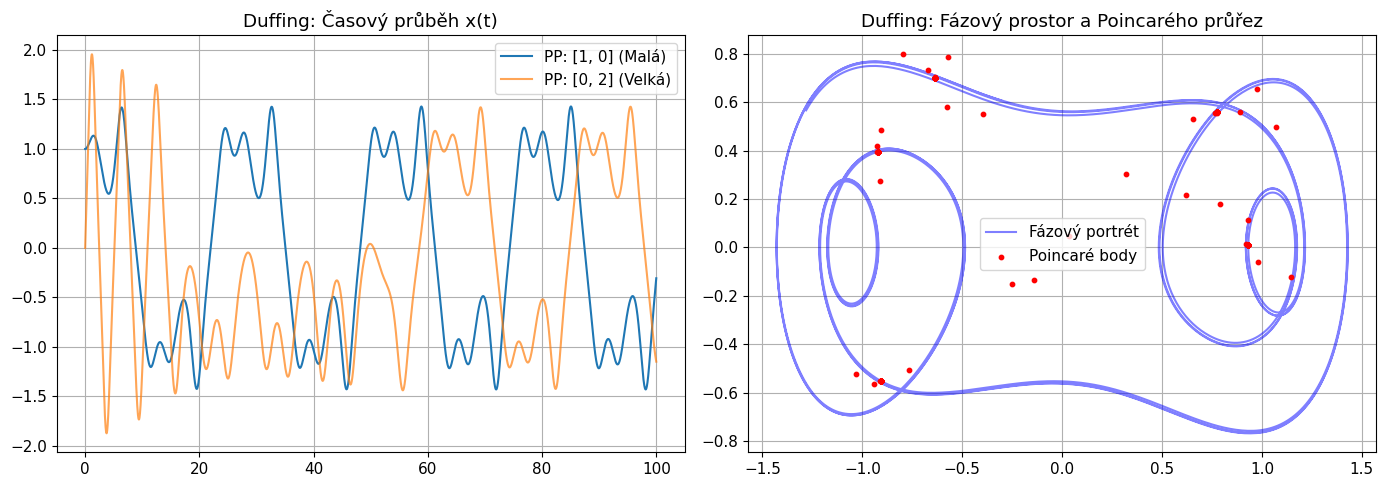

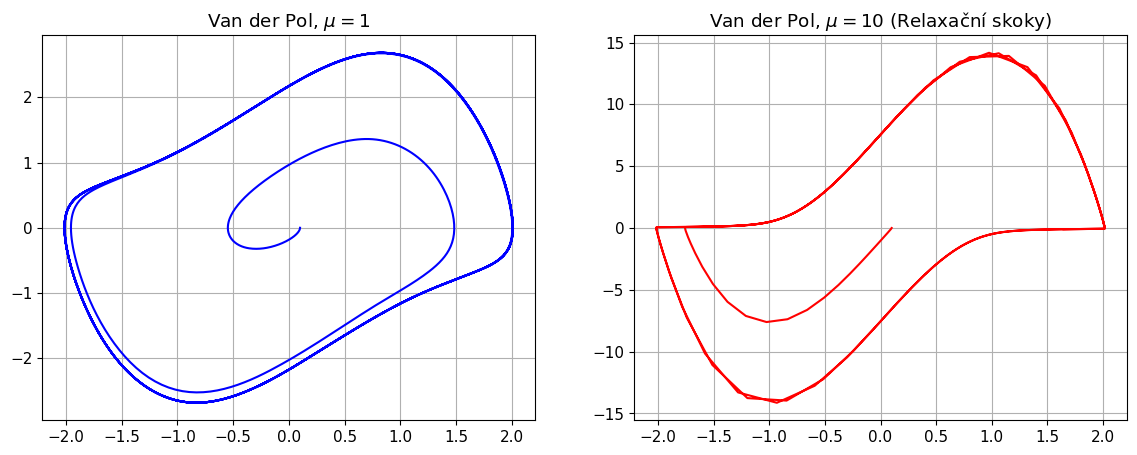

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Globální nastavení vizualizace
plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 5)})

# --- Definice funkcí modelů ---

def linear_oscillator(t, y, m, b, k, F0, omega):
    return [y[1], -(b/m)*y[1] - (k/m)*y[0] + (F0/m)*np.cos(omega*t)]

def duffing_oscillator(t, y, delta, alpha, beta, gamma, omega):
    return [y[1], -delta*y[1] - alpha*y[0] - beta*(y[0]**3) + gamma*np.cos(omega*t)]

def vanderpol_oscillator(t, y, mu):
    return [y[1], mu * (1 - y[0]**2) * y[1] - y[0]]

# --- 1. Lineární oscilátor: Vliv tlumení ---
k, m, y0_lin = 10.0, 1.0, [1.0, 0.0]
b_vals = [1.0, 2*np.sqrt(k*m), 15.0] # Under, Crit, Over
labels = ['Slabé (Under)', 'Kritické', 'Silné (Over)']

plt.figure(figsize=(10, 4))
for b, label in zip(b_vals, labels):
    sol = solve_ivp(linear_oscillator, (0, 15), y0_lin, args=(m, b, k, 0, 0), t_eval=np.linspace(0, 15, 500))
    plt.plot(sol.t, sol.y[0], label=label, linewidth=2)

plt.title("Lineární tlumený oscilátor: Návrat z výchylky x=1")
plt.xlabel("Čas t")
plt.ylabel("Výchylka x")
plt.grid(True)
plt.legend()
plt.show()

# --- 2. Nelineární Duffingův oscilátor ---
# Parametry dle zadání
d_p = (0.2, -1.0, 1.0, 0.3, 1.2) # delta, alpha, beta, gamma, omega

# Časový průběh x(t) pro 2 PP
sol_d1 = solve_ivp(duffing_oscillator, (0, 100), [1.0, 0.0], args=d_p, t_eval=np.linspace(0, 100, 5000))
sol_d2 = solve_ivp(duffing_oscillator, (0, 100), [0.0, 2.0], args=d_p, t_eval=np.linspace(0, 100, 5000))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(sol_d1.t, sol_d1.y[0], label='PP: [1, 0] (Malá)')
axs[0].plot(sol_d2.t, sol_d2.y[0], label='PP: [0, 2] (Velká)', alpha=0.7)
axs[0].set_title("Duffing: Časový průběh x(t)")
axs[0].legend()
axs[0].grid(True)

# Fázový diagram + Poincaré
axs[1].plot(sol_d1.y[0][1000:], sol_d1.y[1][1000:], color='blue', alpha=0.5, label='Fázový portrét') # bez přechoďáku

# Poincarého průřez (vzorkování T)
T = 2 * np.pi / d_p[4]
sol_p = solve_ivp(duffing_oscillator, (0, 1000), [1.0, 0.0], args=d_p, t_eval=np.arange(0, 1000, T), method='Radau')
axs[1].scatter(sol_p.y[0][20:], sol_p.y[1][20:], s=10, color='red', zorder=5, label='Poincaré body')
axs[1].set_title("Duffing: Fázový prostor a Poincarého průřez")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()

# --- 3. Van der Polův oscilátor: Limitní cykly ---
sol_v1 = solve_ivp(vanderpol_oscillator, (0, 50), [0.1, 0.0], args=(1.0,), t_eval=np.linspace(0, 50, 2000))
sol_v10 = solve_ivp(vanderpol_oscillator, (0, 50), [0.1, 0.0], args=(10.0,), t_eval=np.linspace(0, 50, 2000), method='Radau')

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(sol_v1.y[0], sol_v1.y[1], color='blue')
axs[0].set_title(r"Van der Pol, $\mu=1$")
axs[0].grid(True)
axs[1].plot(sol_v10.y[0], sol_v10.y[1], color='red')
axs[1].set_title(r"Van der Pol, $\mu=10$ (Relaxační skoky)")
axs[1].grid(True)
plt.show()


---
## Úloha 2: Programová implementace SIR modelu

Rovnice přeprogramované pro 5 vybraných nemocí (Chřipka, Ebola, SARS, Příušnice, Spalničky) s odlišným základním reprodukčním číslem $R_0$. Průměrná doba infekčnosti $\gamma = 0.1$.

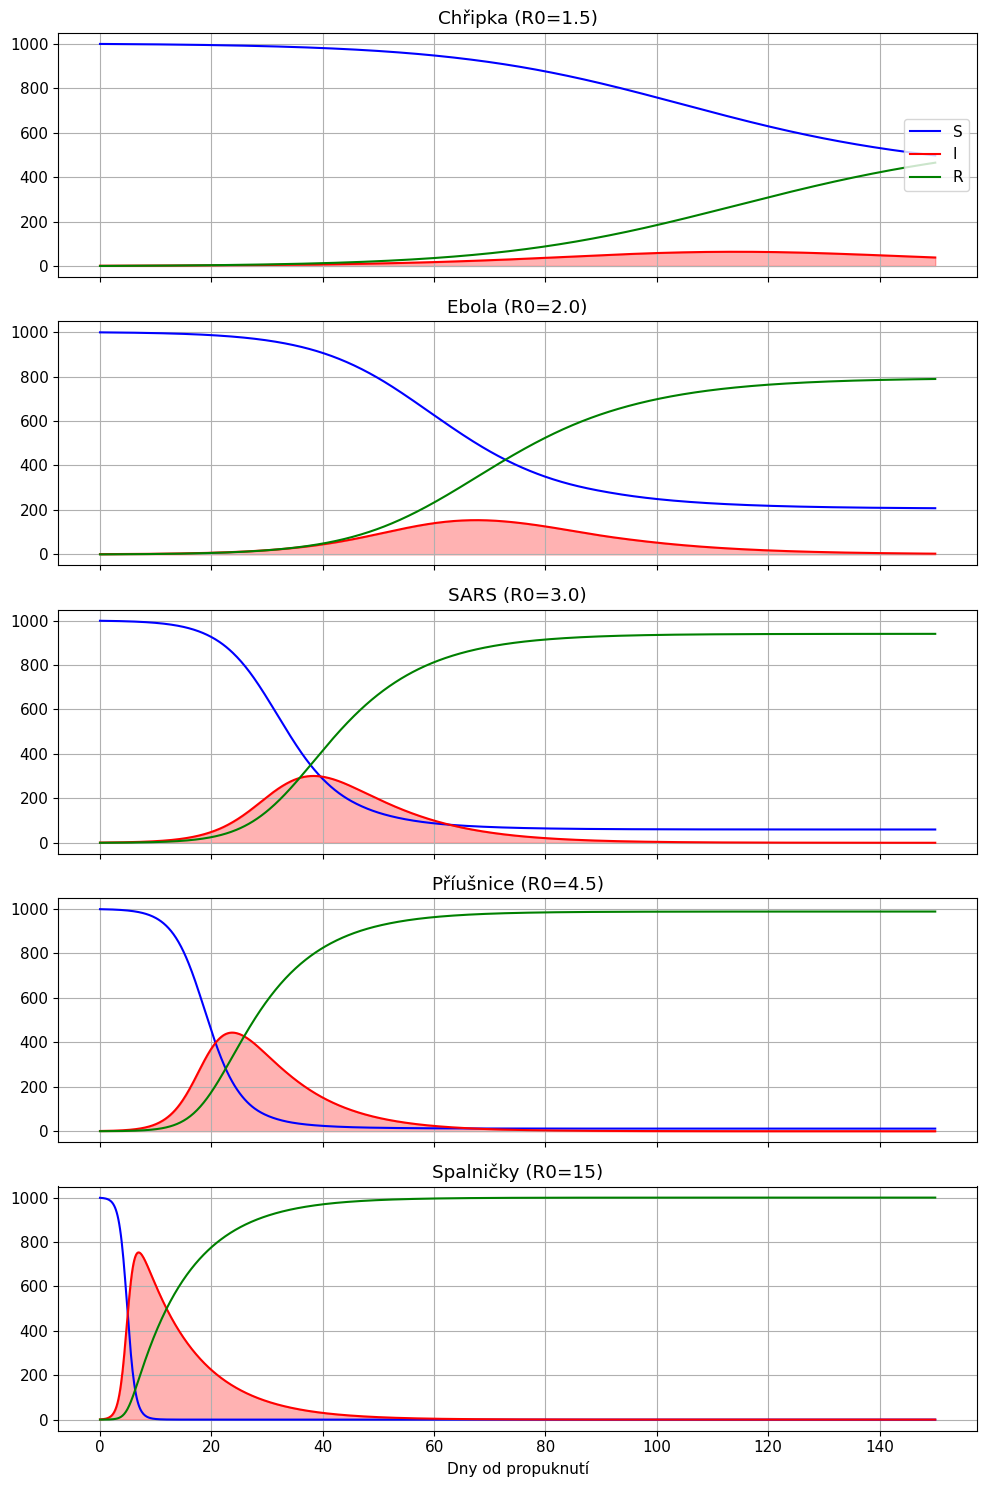

In [2]:
def sir_model_eq(t, y, N, beta, gamma):
    return [-beta * y[0] * y[1] / N, (beta * y[0] * y[1] / N) - gamma * y[1], gamma * y[1]]

N, y0_sir, gamma = 1000, [999, 1, 0], 0.1
diseases = {
    "Chřipka (R0=1.5)": 1.5, 
    "Ebola (R0=2.0)": 2.0, 
    "SARS (R0=3.0)": 3.0, 
    "Příušnice (R0=4.5)": 4.5, 
    "Spalničky (R0=15)": 15.0
}

fig, axs = plt.subplots(5, 1, figsize=(10, 15), sharex=True)
for i, (name, r0) in enumerate(diseases.items()):
    beta = r0 * gamma
    sol = solve_ivp(sir_model_eq, (0, 150), y0_sir, args=(N, beta, gamma), t_eval=np.linspace(0, 150, 1000))
    
    axs[i].plot(sol.t, sol.y[0], label="S", color='blue')
    axs[i].plot(sol.t, sol.y[1], label="I", color='red')
    # Zabarvení plochy nakažených pro lepší vizualizaci 'vlny'
    axs[i].fill_between(sol.t, sol.y[1], color='red', alpha=0.3)
    axs[i].plot(sol.t, sol.y[2], label="R", color='green')
    axs[i].set_title(name)
    axs[i].grid(True)
    if i == 0: axs[i].legend(loc='center right')
    
axs[-1].set_xlabel("Dny od propuknutí")
plt.tight_layout()
plt.show()


---

## Úloha 3: Vytvoření vlastního modelu – Pravděpodobnostní Monte Carlo Generátor Umění

Zvolena **možnost 3 (Pravděpodobnostní Monte Carlo model)**.

Tento model simuluje chování více agentů, kteří provádějí náhodnou procházku (Random Walk) na 2D plátně. Jde o Monte Carlo metodu, protože každý krok agenta je určen náhodným vzorkováním ze dvou pravděpodobnostních rozdělení:

1.  **Úhel kroku $\theta$:** Je vzorkován z **rovnoměrného rozdělení** $U(0, 2\pi)$.
2.  **Délka kroku $l$:** Je vzorkována z **normálního (Gaussova) rozdělení** $N(\mu, \sigma)$.

Opakovaným vzorkováním těchto náhodných veličin po tisíce kroků generujeme unikátní, nepředvídatelnou trajektorii. Vizualizací trajektorií více agentů s dynamickými barvami a průhledností vytváříme abstraktní umění.

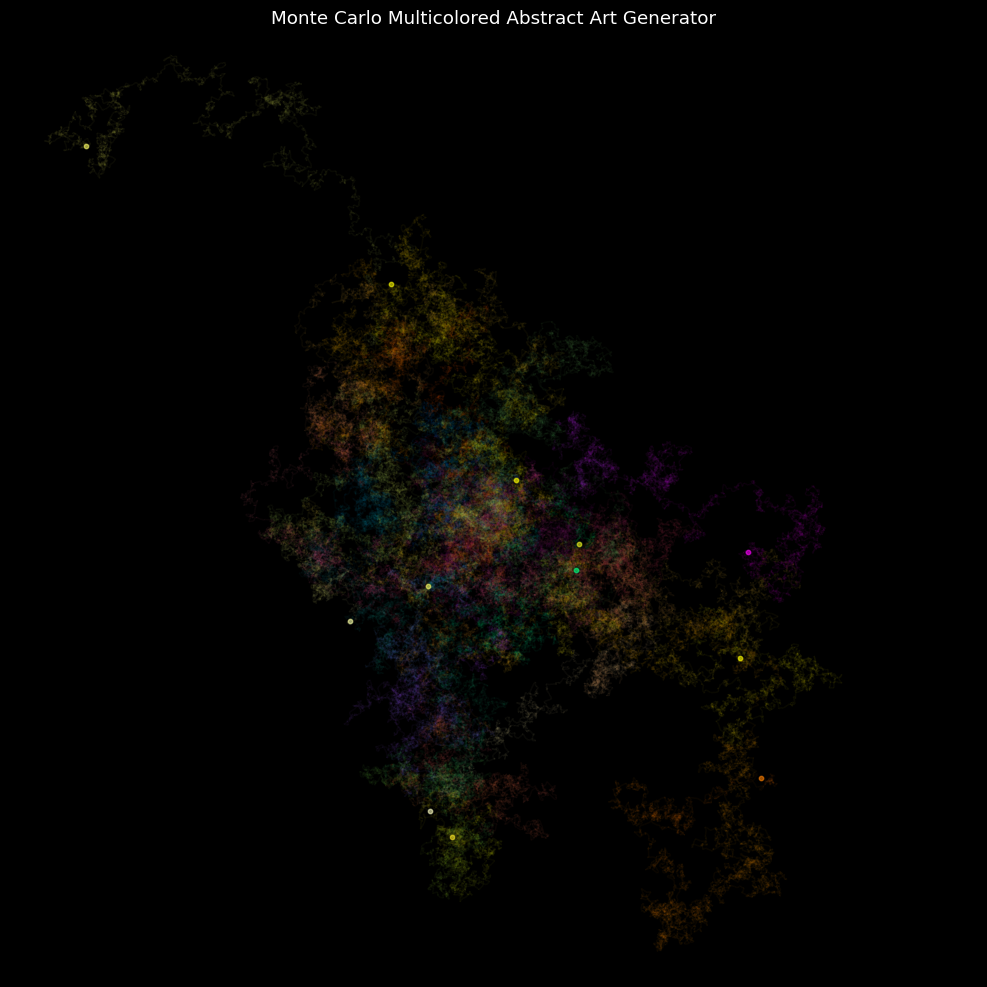

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Nastavení vizualizace pro umění
plt.style.use('dark_background')

# Monte Carlo parametry
num_agents = 12         # Počet 'umělců'
num_steps = 15000        # Délka procházky (trials)
step_mu = 1.0           # Průměrná délka kroku
step_sigma = 10        # Směrodatná odchylka kroku

# Inicializace pozic (všichni začínají v [0, 0])
positions = np.zeros((num_agents, num_steps + 1, 2))

# Jádro Monte Carlo simulace
for s in range(1, num_steps + 1):
    # Vzorkování pravděpodobnostních veličin (Monte Carlo krok)
    angles = np.random.uniform(0, 2 * np.pi, num_agents)
    step_lengths = np.random.normal(step_mu, step_sigma, num_agents)
    
    # Výpočet deterministických změn pozice
    dx = step_lengths * np.cos(angles)
    dy = step_lengths * np.sin(angles)
    
    # Aktualizace pozice agentů
    positions[:, s, 0] = positions[:, s-1, 0] + dx
    positions[:, s, 1] = positions[:, s-1, 1] + dy

# Vizualizace abstraktního umění s více barvami
fig, ax = plt.subplots(figsize=(10, 10))

# Definice různých barevných map (colormaps) pro agenty
cmaps = [plt.cm.spring, plt.cm.summer, plt.cm.autumn, plt.cm.winter,
         plt.cm.cool, plt.cm.Wistia, plt.cm.magma, plt.cm.plasma,
         plt.cm.viridis, plt.cm.inferno]

for i in range(num_agents):
    # Výběr barvy pro agenta z jeho mapy, s postupnou změnou intenzity podél procházky
    color_intensities = np.linspace(0.3, 1.0, num_steps + 1)
    cmap = cmaps[i % len(cmaps)] # cyklování map
    agent_colors = cmap(color_intensities)
    
    # Vykreslení trajektorie s dynamickou změnou barvy a vysokou průhledností
    # Protože ax.plot nepodporuje pole barev přímo, musíme použít LineCollection nebo scatter pro segmenty,
    # ale scatter je pomalý. Nejefektivnější je použít LineCollection.
    from matplotlib.collections import LineCollection
    points = positions[i, :, :].reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1), alpha=0.04, linewidth=1.2)
    # Set the values used for colormapping
    lc.set_array(color_intensities)
    ax.add_collection(lc)
    
    # Vykreslení koncového bodu s plnou barvou pro zvýraznění
    ax.scatter(positions[i, -1, 0], positions[i, -1, 1], color=agent_colors[-1], s=10, alpha=0.6, zorder=10)

# Nastavení limitů grafu podle rozptylu agentů
all_pos = positions.reshape(-1, 2)
max_val = np.max(np.abs(all_pos)) * 1.05
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)

ax.set_title("Monte Carlo Multicolored Abstract Art Generator")
plt.axis('off')
plt.tight_layout()
plt.show()
